In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
%matplotlib inline
set_matplotlib_formats("svg", "pdf")
from matplotlib.colors import to_rgba
import seaborn as sns

sns.set_theme()

from tqdm.notebook import tqdm

print("torch version:", torch.__version__)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", device)

torch version: 2.11.0+cu128
device: cuda


In [ ]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        return self.seq(x)

In [3]:
model = Classifier().to(device)
print(model)

Classifier(
  (seq): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [4]:
class XORDataset(data.Dataset):
    def __init__(self, size, std=0.1):
        super().__init__()
        self.size = size
        self.std = std
        self.generate()
        
    def generate(self):
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.float32)
        data += self.std * torch.randn(data.shape)
        self.data = data
        self.label = label
    
    def __len__(self):
        return self.size
    
    def __getitem__(self, idx):
        return self.data[idx], self.label[idx]

In [5]:
dataset = XORDataset(size=1000, std=0.25)

In [ ]:
def vis(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
        
    data_0 = data[label == 0]
    data_1 = data[label == 1]
    
    plt.figure(figsize=(4, 4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="class 1")
    plt.title("dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

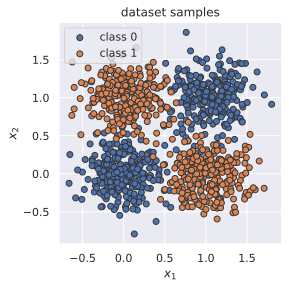

In [7]:
vis(dataset.data, dataset.label)
plt.show()

In [8]:
loss_module = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-2)

In [16]:
train_dataset = XORDataset(size=64000)
train_dataloader = data.DataLoader(train_dataset, batch_size=1024, shuffle=True)

In [17]:
def train_model(model, optimizer, dataloader, loss_module, n_epochs=1000):
    model.train()
    for epoch in tqdm(range(n_epochs)):
        avg_loss = 0
        for x, y in dataloader:
            optimizer.zero_grad()
            x = x.to(device)
            y = y.to(device)
            y_ = model(x).squeeze(dim=1)
            loss = loss_module(y_, y)
            loss.backward()
            optimizer.step()
            avg_loss += loss.item()
        avg_loss /= len(dataloader)
        if epoch % 10 == 0:
            tqdm.write(f"epoch: {epoch} loss: {avg_loss}")

In [18]:
train_model(model, optimizer, train_dataloader, loss_module)

  0%|          | 0/1000 [00:00<?, ?it/s]

epoch: 0 loss: 0.14950449519882533
epoch: 10 loss: 4.195768990629158e-06
epoch: 20 loss: 5.325137827019225e-06
epoch: 30 loss: 2.266489219429844e-06
epoch: 40 loss: 1.3899181367612924e-06
epoch: 50 loss: 9.960914920405967e-07
epoch: 60 loss: 5.679841482080722e-07
epoch: 70 loss: 5.093941077062944e-07
epoch: 80 loss: 3.4177770279105366e-06
epoch: 90 loss: 1.1625146697273494e-06
epoch: 100 loss: 9.67212599789491e-07
epoch: 110 loss: 7.864154454976429e-07
epoch: 120 loss: 7.455703758924279e-07
epoch: 130 loss: 7.182623937029665e-07
epoch: 140 loss: 6.179028618575218e-07
epoch: 150 loss: 1.8478623773989154e-06
epoch: 160 loss: 3.2555013619335186e-06
epoch: 170 loss: 4.248157032244697e-06
epoch: 180 loss: 5.681439271635706e-06
epoch: 190 loss: 7.4447649882448975e-06
epoch: 200 loss: 8.053374215936827e-06
epoch: 210 loss: 5.229676760553134e-06
epoch: 220 loss: 3.905561965121518e-06
epoch: 230 loss: 2.843909418703651e-06
epoch: 240 loss: 1.8430245997283886e-06
epoch: 250 loss: 1.1591154725285

In [19]:
torch.save(model.state_dict(), "alpha.pth")

In [20]:
test_dataset = XORDataset(size=1024)
test_data_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)

In [ ]:
def eval_model(model, data_loader):
    model.eval()
    true_y, n_y = 0., 0.
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            y_ = model(x).squeeze(dim=1)
            y_ = torch.sigmoid(y_)
            y_lbl = (y_ >= 0.5).float()
            true_y += (y_lbl == y).sum()
            n_y += y.shape[0]
    acc = true_y / n_y
    print(f"acc: {100.0*acc:4.2f}%")

In [22]:
eval_model(model, test_data_loader)

acc: 100.00%
